In [33]:
import tensorflow as tf
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense


In [2]:
print(tf.__version__)

2.21.0


In [3]:
X_train = joblib.load("../data/processed/X_train.pkl")
X_val = joblib.load("../data/processed/X_val.pkl")
X_test = joblib.load("../data/processed/X_test.pkl")

y_train = joblib.load("../data/processed/y_train.pkl")
y_val = joblib.load("../data/processed/y_val.pkl")
y_test = joblib.load("../data/processed/y_test.pkl")

In [4]:
model = Sequential([
    Dense(64, activation="relu", input_shape=(X_train.shape[1],)),
    Dense(32, activation="relu"),
    Dense(16, activation="relu"),
    Dense(1, activation="sigmoid")
])

c:\Users\Acer\.conda\envs\co\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [5]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.AUC(name="auc")
    ]
    )

In [6]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,609 (18.00 KB)

 Trainable params: 4,609 (18.00 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    verbose=1
)

Epoch 1/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.7701 - auc: 0.8041 - loss: 0.4599 - val_accuracy: 0.8101 - val_auc: 0.8466 - val_loss: 0.4191
Epoch 2/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8008 - auc: 0.8400 - loss: 0.4233 - val_accuracy: 0.8154 - val_auc: 0.8465 - val_loss: 0.4166
Epoch 3/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8005 - auc: 0.8468 - loss: 0.4149 - val_accuracy: 0.8172 - val_auc: 0.8461 - val_loss: 0.4167
Epoch 4/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8076 - auc: 0.8531 - loss: 0.4074 - val_accuracy: 0.8181 - val_auc: 0.8469 - val_loss: 0.4153
Epoch 5/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8099 - auc: 0.8573 - loss: 0.4024 - val_accuracy: 0.8163 - val_auc: 0.8459 - val_loss: 0.4151
Epoch 6/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8110 - auc: 0.8610 - loss: 0.3976 - val_accuracy: 0.8128 - val_auc: 0.8445 - val_loss: 0.4201
Epoch 7/100
141/141 ━━━━━━━━━━━━━━

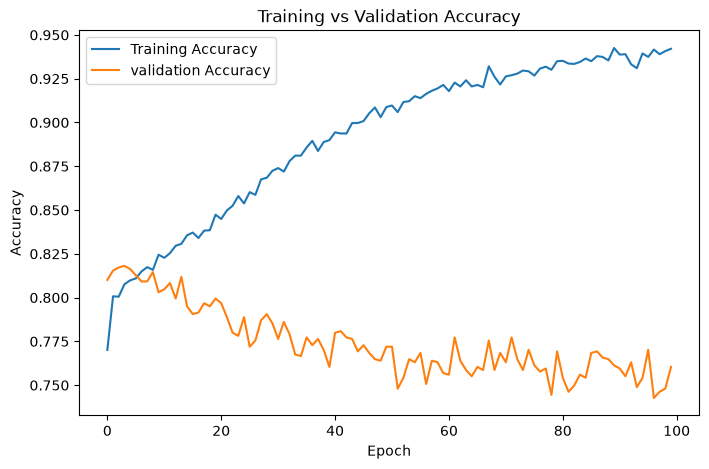

In [11]:
plt.figure(figsize=(8, 5))
plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="validation Accuracy"
)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

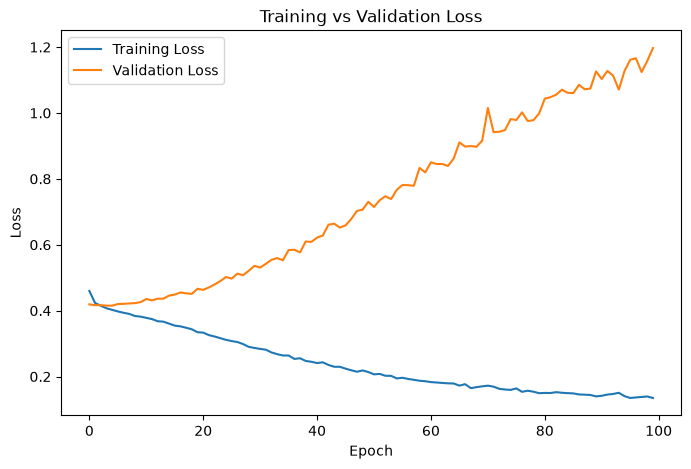

In [13]:
plt.figure(figsize=(8, 5))
plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

### Improve the ANN with Dropout

In [16]:
from tensorflow.keras.layers import Dropout

model = Sequential([
    Dense(64, activation="relu", input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(32, activation="relu"),
    Dropout(0.3),
    Dense(16, activation="relu"),
    Dense(1, activation="sigmoid")
])

In [17]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.AUC(name="auc")
    ]
)

In [18]:
from tensorflow.keras.callbacks import EarlyStopping

In [19]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

In [20]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.7391 - auc: 0.7431 - loss: 0.5094 - val_accuracy: 0.7773 - val_auc: 0.8212 - val_loss: 0.4576
Epoch 2/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7717 - auc: 0.8093 - loss: 0.4584 - val_accuracy: 0.8066 - val_auc: 0.8357 - val_loss: 0.4343
Epoch 3/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7861 - auc: 0.8232 - loss: 0.4432 - val_accuracy: 0.8004 - val_auc: 0.8375 - val_loss: 0.4316
Epoch 4/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7903 - auc: 0.8294 - loss: 0.4359 - val_accuracy: 0.8057 - val_auc: 0.8406 - val_loss: 0.4259
Epoch 5/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7939 - auc: 0.8326 - loss: 0.4334 - val_accuracy: 0.8039 - val_auc: 0.8405 - val_loss: 0.4269
Epoch 6/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7963 - auc: 0.8373 - loss: 0.4265 - val_accuracy: 0.8137 - val_auc: 0.8419 - val_loss: 0.4218
Epoch 7/100
141/141 ━━━━━━━━━━━━━━

### Add Learning Rate Reduction

In [21]:
from tensorflow.keras.callbacks import ReduceLROnPlateau

In [22]:
reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=5,
    min_lr=1e-6
)

In [23]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[
        early_stopping,
        reduce_lr
    ],
    verbose=1
)

Epoch 1/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8028 - auc: 0.8483 - loss: 0.4145 - val_accuracy: 0.8154 - val_auc: 0.8422 - val_loss: 0.4186 - learning_rate: 0.0010
Epoch 2/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8076 - auc: 0.8460 - loss: 0.4171 - val_accuracy: 0.8101 - val_auc: 0.8425 - val_loss: 0.4203 - learning_rate: 0.0010
Epoch 3/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8041 - auc: 0.8470 - loss: 0.4166 - val_accuracy: 0.8119 - val_auc: 0.8420 - val_loss: 0.4208 - learning_rate: 0.0010
Epoch 4/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8074 - auc: 0.8509 - loss: 0.4114 - val_accuracy: 0.8075 - val_auc: 0.8422 - val_loss: 0.4234 - learning_rate: 0.0010
Epoch 5/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8014 - auc: 0.8501 - loss: 0.4127 - val_accuracy: 0.8137 - val_auc: 0.8410 - val_loss: 0.4216 - learning_rate: 0.0010
Epoch 6/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8063 - a

### Evaluate

In [30]:
results = model.evaluate(
    X_test,
    y_test,
    verbose=0
)
print(f"Test Loss:{results[0]}")
print(f"Test Accuracy:{results[1]}")
print(f"Test AUC:{results[2]}")

Test Loss:0.42657357454299927
Test Accuracy:0.7906316518783569
Test AUC:0.8373156189918518


In [25]:
y_prob = model.predict(X_test)

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [26]:
y_pred = (y_prob >= 0.5).astype(int)

In [27]:
y_pred

array([[0],
       [1],
       [0],
       ...,
       [0],
       [0],
       [0]], shape=(1409, 1))

In [31]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.84      0.88      0.86      1035
           1       0.62      0.55      0.58       374

    accuracy                           0.79      1409
   macro avg       0.73      0.71      0.72      1409
weighted avg       0.78      0.79      0.79      1409



In [32]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[910 125]
 [170 204]]


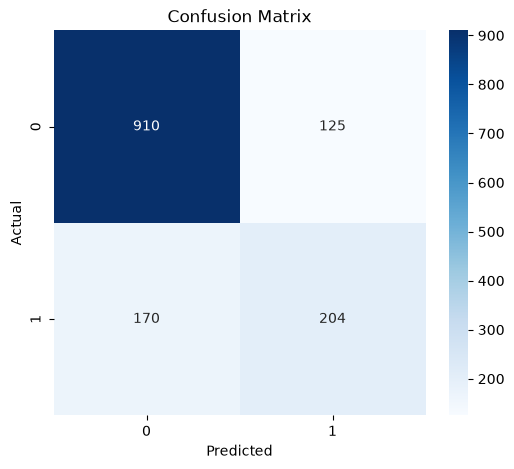

In [34]:
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [35]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y_test, y_prob)
print("ROC-AUC:", auc)

ROC-AUC: 0.8374589888656385


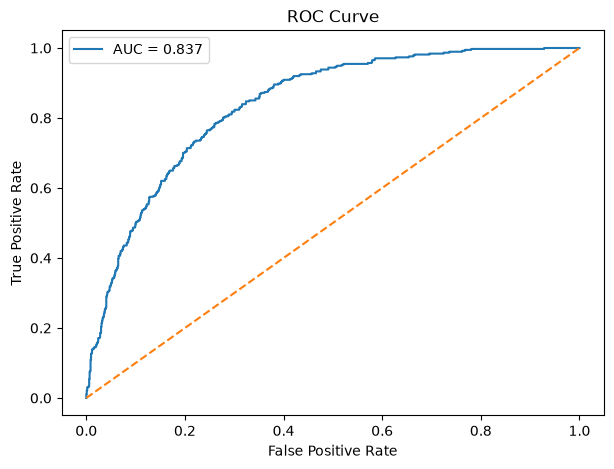

In [36]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr,tpr,label=f"AUC = {auc:.3f}")

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

In [37]:
model.save("../models/churn_ann.h5")